# Potato Leaf Disease Detection — Comparative Deep Learning Evaluation
---

## Methodology

Four model configurations are trained and evaluated identically on the same held-out test set:

1. **EfficientNetB3 (frozen backbone)** - transfer learning baseline, feature extraction only
2. **EfficientNetB3 (fine-tuned)** - last 30 layers unfrozen with a reduced learning rate
3. **MobileNetV2 (frozen backbone)** -lightweight, edge-deployable alternative
4. **Custom CNN (trained from scratch)** - baseline showing what transfer learning contributes.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import time
import json
import shutil

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import EfficientNetB3, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, accuracy_score)
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

import cv2

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)


I0000 00:00:1783326953.654046   58558 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

## 1. Local Dataset Paths

In [ ]:
# Local paths by 01_data_augmentation.ipynb. Adjust if your folder layout differs.
train_dir = 'PlantVillage_Augmented_Dataset/train'
val_dir   = 'PlantVillage_Augmented_Dataset/val'
test_dir  = 'PlantVillage_Augmented_Dataset/test'

for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    assert os.path.isdir(split_dir), f"Missing folder: {split_dir} -- run 01_data_augmentation.ipynb first"
    classes_found = sorted(os.listdir(split_dir))
    print(f"{split_name}: {classes_found}")
    for c in classes_found:
        n = len(os.listdir(os.path.join(split_dir, c)))
        print(f"   {c}: {n} images")

CLASS_NAMES = sorted(os.listdir(train_dir))
print("\nClass order (index 0, 1, 2, ...):", CLASS_NAMES)


train: ['Early_blight', 'Healthy', 'Late_blight']
   Early_blight: 1400 images
   Healthy: 1000 images
   Late_blight: 1400 images
val: ['Early_blight', 'Healthy', 'Late_blight']
   Early_blight: 150 images
   Healthy: 23 images
   Late_blight: 150 images
test: ['Early_blight', 'Healthy', 'Late_blight']
   Early_blight: 150 images
   Healthy: 23 images
   Late_blight: 150 images

Class order (index 0, 1, 2, ...): ['Early_blight', 'Healthy', 'Late_blight']


              train  val  test
Early_blight   1400  150   150
Healthy        1000   23    23
Late_blight    1400  150   150


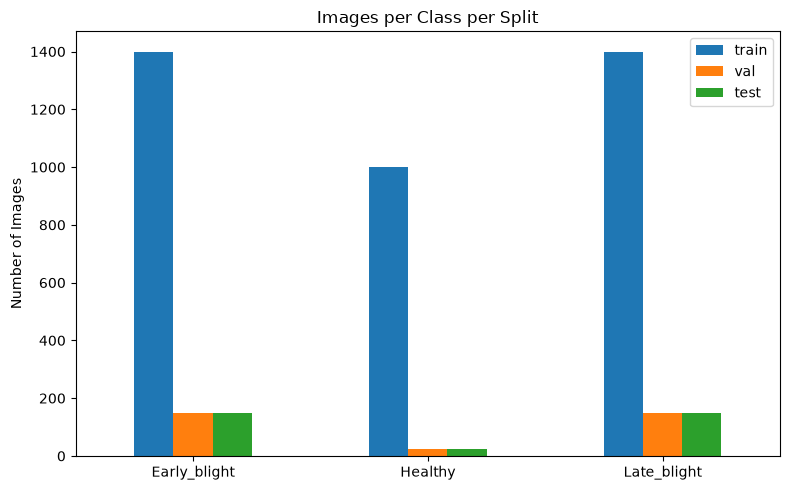

In [4]:
counts = {}
for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    counts[split_name] = {c: len(os.listdir(os.path.join(split_dir, c))) for c in CLASS_NAMES}

counts_df = pd.DataFrame(counts)
print(counts_df)

counts_df.plot(kind='bar', figsize=(8, 5))
plt.title('Images per Class per Split')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Data Generators and Class Weights

In [5]:
BATCH_SIZE = 16

def make_generators(preprocess_fn, target_size, batch_size=BATCH_SIZE):
    """Train/val/test are already pre-split and pre-augmented (train only) as separate folders
    on disk. No further augmentation is applied here"""
    datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = datagen.flow_from_directory(
        train_dir, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', classes=CLASS_NAMES, shuffle=True, seed=42
    )
    val_gen = datagen.flow_from_directory(
        val_dir, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', classes=CLASS_NAMES, shuffle=False
    )
    test_gen = datagen.flow_from_directory(
        test_dir, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', classes=CLASS_NAMES, shuffle=False
    )
    return train_gen, val_gen, test_gen


def get_class_weights(train_gen):
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen.classes),
        y=train_gen.classes
    )
    return dict(enumerate(weights))


## 3. Model Architectures

In [6]:
def build_transfer_model(base_model_fn, input_shape, num_classes=3, fine_tune_last_n=0, learning_rate=1e-4):
    """fine_tune_last_n=0 -> fully frozen backbone (feature extraction).
    fine_tune_last_n=N -> unfreeze the last N layers of the backbone for fine-tuning
    (use a smaller learning_rate when fine-tuning to avoid destroying pretrained weights)."""
    
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)

    if fine_tune_last_n == 0:
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers[:-fine_tune_last_n]:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_custom_cnn(input_shape, num_classes=3):
    """Trained entirely from scratch -- baseline for how much transfer learning contributes."""
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


## 4. Unified Training and Evaluation

In [7]:
def train_and_evaluate(model_name, model, train_gen, val_gen, test_gen, class_weights_dict, epochs=50, patience=7):
    checkpoint_path = f'best_{model_name}.keras'
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=max(3, patience // 2), min_lr=1e-7)
    ]

    start = time.time()
    history = model.fit(
        train_gen,
        steps_per_epoch=max(1, train_gen.samples // train_gen.batch_size),
        validation_data=val_gen,
        validation_steps=max(1, val_gen.samples // val_gen.batch_size),
        epochs=epochs,
        class_weight=class_weights_dict,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start

    best_model = load_model(checkpoint_path)

    # TRUE held out test evaluation
    test_gen.reset()
    y_true = test_gen.classes
    steps = int(np.ceil(test_gen.samples / test_gen.batch_size))
    y_pred_probs = best_model.predict(test_gen, steps=steps)
    y_pred = np.argmax(y_pred_probs, axis=1)[:len(y_true)]

    ordered_class_names = sorted(test_gen.class_indices, key=test_gen.class_indices.get)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    report_dict = classification_report(y_true, y_pred, target_names=ordered_class_names, output_dict=True)

    print(f"\n{'='*60}")
    print(f"{model_name} -- TEST SET RESULTS (held-out, never trained on)")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=ordered_class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=ordered_class_names).plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(f'{model_name} -- Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()

    results = {
        'model_name': model_name,
        'test_accuracy': acc,
        'test_f1_macro': f1_macro,
        'train_time_sec': train_time,
        'num_params': model.count_params(),
        'history': history.history,
        'classification_report': report_dict
    }
    return best_model, results


## Grad-CAM — Visual Explanation of Predictions

In [ ]:
def make_gradcam_heatmap(img_array_batch, model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            shape = layer.output.shape          
            if shape is not None and len(shape) == 4:
                last_conv_layer_name = layer.name
                break

    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array_batch)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())


def show_gradcam(img_path, model, preprocess_fn, target_size, class_names_ordered):
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array_batch = np.expand_dims(preprocess_fn(img_array.copy()), axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(img_array_batch, model)

    heatmap_resized = cv2.resize(heatmap, target_size)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(np.clip(img_array * 0.6 + heatmap_colored * 0.4, 0, 255))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_array.astype('uint8'))
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Overlay -- Predicted: {class_names_ordered[pred_idx]}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


## 5. Train and Compare All Four Configurations

Runs locally on your machine now, not Kaggle. If you don't have a GPU available in VS Code,
expect this to be considerably slower -- consider reducing `epochs`/`patience` for a first pass,
or running on Google Colab with a GPU runtime if local training is impractically slow.


In [9]:
all_results = {}
trained_models = {}


In [18]:
all_results.items()

dict_items([('MobileNetV2', {'model_name': 'MobileNetV2', 'test_accuracy': 0.9721362229102167, 'test_f1_macro': 0.9465545082936387, 'train_time_sec': 219.09627962112427, 'num_params': 2915395, 'history': {'accuracy': [0.8078752756118774, 0.9375, 0.920718789100647, 0.875, 0.9439746141433716, 0.875, 0.9526955485343933, 1.0, 0.9579809904098511, 0.9375, 0.9574524164199829, 0.9375, 0.9632663726806641, 1.0, 0.9659090638160706, 1.0, 0.9659090638160706, 1.0, 0.9693446159362793, 1.0, 0.9711945056915283, 1.0, 0.9704017043113708, 1.0, 0.9717230200767517, 1.0, 0.9674947261810303], 'loss': [0.4732341766357422, 0.13571730256080627, 0.1915779858827591, 0.12239761650562286, 0.14143623411655426, 0.15962892770767212, 0.12835729122161865, 0.03659503906965256, 0.11302844434976578, 0.19008848071098328, 0.10314276814460754, 0.0975710079073906, 0.09346525371074677, 0.06836004555225372, 0.08625414222478867, 0.013249458745121956, 0.0885668396949768, 0.043454788625240326, 0.08123741298913956, 0.0131387235596776

Found 3800 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Found 323 images belonging to 3 classes.


I0000 00:00:1783309018.542155   20499 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50


I0000 00:00:1783309030.431880   20499 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783309040.797643   20958 service.cc:153] XLA service 0x795c5803a7f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783309040.797677   20958 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783309041.198416   20958 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783309043.719299   20958 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783309044.450658   20958 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25542__.403
E0000 00:00:1783309052.505064   20958 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup 

135/237 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7676 - loss: 0.5582

I0000 00:00:1783309087.545942   20956 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25542__.403
E0000 00:00:1783309099.321286   20956 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


237/237 ━━━━━━━━━━━━━━━━━━━━ 100s 230ms/step - accuracy: 0.8348 - loss: 0.4242 - val_accuracy: 0.9688 - val_loss: 0.1182 - learning_rate: 1.0000e-04
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8750 - loss: 0.2611 - val_accuracy: 0.9656 - val_loss: 0.1195 - learning_rate: 1.0000e-04
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9501 - loss: 0.1578 - val_accuracy: 0.9750 - val_loss: 0.0677 - learning_rate: 1.0000e-04
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 1.0000 - loss: 0.0376 - val_accuracy: 0.9750 - val_loss: 0.0671 - learning_rate: 1.0000e-04
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9638 - loss: 0.1176 - val_accuracy: 0.9781 - val_loss: 0.0502 - learning_rate: 1.0000e-04
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.1032 - val_accuracy: 0.9781 - val_loss: 0.0503 - learning_rate: 1.0000e-04
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 

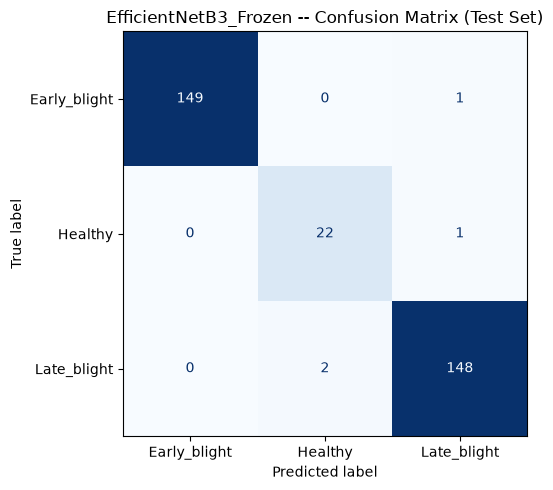

In [8]:
# Model 1: EfficientNetB3 -frozen backbone (baseline)
train_gen, val_gen, test_gen = make_generators(eff_preprocess, target_size=(300, 300))
class_weights_dict = get_class_weights(train_gen)

model_eff_frozen = build_transfer_model(EfficientNetB3, input_shape=(300, 300, 3), fine_tune_last_n=0)
model_eff_frozen, results = train_and_evaluate('EfficientNetB3_Frozen', model_eff_frozen,
                                                 train_gen, val_gen, test_gen, class_weights_dict)
all_results['EfficientNetB3_Frozen'] = results
trained_models['EfficientNetB3_Frozen'] = model_eff_frozen


Found 3800 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Epoch 1/50


I0000 00:00:1783309470.280209   20956 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_103178__.431
W0000 00:00:1783309482.748585   20956 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.27GiB (rounded to 1368785408)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1783309482.748920   20956 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1783309482.748928   20956 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 389, Chunks in use: 389. 97.2KiB allocated for chunks. 97.2KiB in use in bin. 29.6KiB client-requested in use in bin.
I0000 00:00:1783309482.748933   20956 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 222, Chunks in use: 222. 151.5KiB allocated for chunks. 151.5KiB in use in bin. 124.6KiB client-requested in use i

138/237 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.6359 - loss: 0.8737

I0000 00:00:1783309536.911370   20957 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_103178__.431
W0000 00:00:1783309548.320883   20957 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.90GiB (rounded to 2039661056)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1783309548.320976   20957 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1783309548.320983   20957 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 399, Chunks in use: 399. 99.8KiB allocated for chunks. 99.8KiB in use in bin. 29.8KiB client-requested in use in bin.
I0000 00:00:1783309548.320990   20957 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 223, Chunks in use: 223. 152.0KiB allocated for chunks. 152.0KiB in use in bin. 124.9KiB client-requested in use i

237/237 ━━━━━━━━━━━━━━━━━━━━ 155s 356ms/step - accuracy: 0.7183 - loss: 0.7588 - val_accuracy: 0.9438 - val_loss: 0.3479 - learning_rate: 1.0000e-05
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8125 - loss: 0.4619 - val_accuracy: 0.9438 - val_loss: 0.3468 - learning_rate: 1.0000e-05
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.9112 - loss: 0.3722 - val_accuracy: 0.9594 - val_loss: 0.1684 - learning_rate: 1.0000e-05
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9375 - loss: 0.1780 - val_accuracy: 0.9594 - val_loss: 0.1681 - learning_rate: 1.0000e-05
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.9413 - loss: 0.2347 - val_accuracy: 0.9719 - val_loss: 0.1098 - learning_rate: 1.0000e-05
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9375 - loss: 0.2420 - val_accuracy: 0.9719 - val_loss: 0.1095 - learning_rate: 1.0000e-05
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy

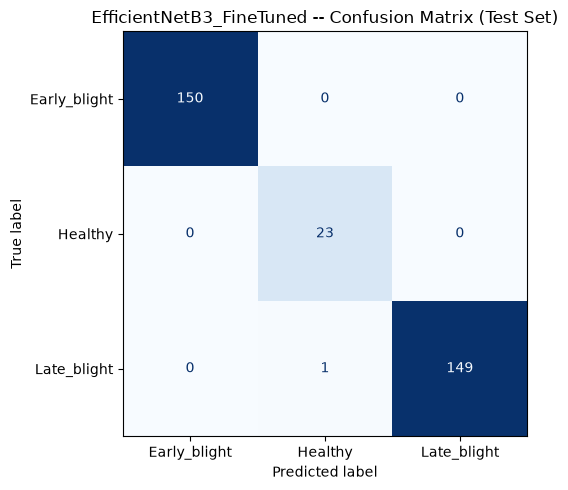

In [9]:
# Model 2: EfficientNetB3 - fine-tuned (unfreeze last 30 layers, lower LR)
train_gen, val_gen, test_gen = make_generators(eff_preprocess, target_size=(300, 300))
class_weights_dict = get_class_weights(train_gen)

model_eff_ft = build_transfer_model(EfficientNetB3, input_shape=(300, 300, 3),
                                     fine_tune_last_n=30, learning_rate=1e-5)
model_eff_ft, results = train_and_evaluate('EfficientNetB3_FineTuned', model_eff_ft,
                                             train_gen, val_gen, test_gen, class_weights_dict)
all_results['EfficientNetB3_FineTuned'] = results
trained_models['EfficientNetB3_FineTuned'] = model_eff_ft


In [10]:
model_eff_frozen = load_model('best_EfficientNetB3_Frozen.keras')
model_eff_ft = load_model('best_EfficientNetB3_FineTuned.keras')

I0000 00:00:1783326974.670905   58558 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 3800 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50


I0000 00:00:1783327141.131420   58558 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783327148.219134   58748 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22481__.124


154/237 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7496 - loss: 0.5931

I0000 00:00:1783327175.738468   58748 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22481__.124


237/237 ━━━━━━━━━━━━━━━━━━━━ 61s 161ms/step - accuracy: 0.8079 - loss: 0.4732 - val_accuracy: 0.9563 - val_loss: 0.1350 - learning_rate: 1.0000e-04
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9375 - loss: 0.1357 - val_accuracy: 0.9531 - val_loss: 0.1359 - learning_rate: 1.0000e-04
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9207 - loss: 0.1916 - val_accuracy: 0.9812 - val_loss: 0.0605 - learning_rate: 1.0000e-04
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8750 - loss: 0.1224 - val_accuracy: 0.9812 - val_loss: 0.0610 - learning_rate: 1.0000e-04
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.9440 - loss: 0.1414 - val_accuracy: 0.9844 - val_loss: 0.0445 - learning_rate: 1.0000e-04
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8750 - loss: 0.1596 - val_accuracy: 0.9812 - val_loss: 0.0442 - learning_rate: 1.0000e-04
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.

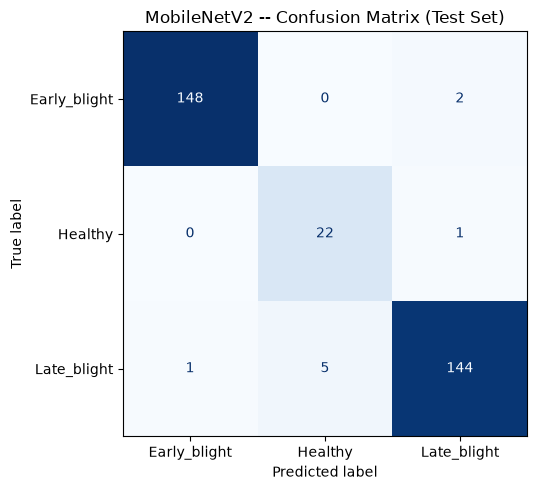

In [13]:
# Model 3: MobileNetV2 - frozen backbone (lightweight, edge-deployable)
K.clear_session()

train_gen, val_gen, test_gen = make_generators(mobilenet_preprocess, target_size=(224, 224))
class_weights_dict = get_class_weights(train_gen)

model_mobilenet = build_transfer_model(MobileNetV2, input_shape=(224, 224, 3), fine_tune_last_n=0)
model_mobilenet, results = train_and_evaluate('MobileNetV2', model_mobilenet,
                                                train_gen, val_gen, test_gen, class_weights_dict)
all_results['MobileNetV2'] = results
trained_models['MobileNetV2'] = model_mobilenet


In [12]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Manual testing on external data
img_path = 'External_Test_Data/L1.png'  # path to YOUR image

img = load_img(img_path, target_size=(300, 300))          # match models input size
arr = img_to_array(img)
arr = eff_preprocess(arr.copy())                            # match models preprocessing
arr = arr.reshape(1, *arr.shape)

probs = model_eff_ft.predict(arr, verbose=0)[0]
pred_idx = probs.argmax()

print(f"Predicted: {CLASS_NAMES[pred_idx]}")
print(f"True label: Healthy")
print(f"Confidence: {probs[pred_idx]*100:.2f}%")

Predicted: Healthy
True label: Healthy
Confidence: 99.98%


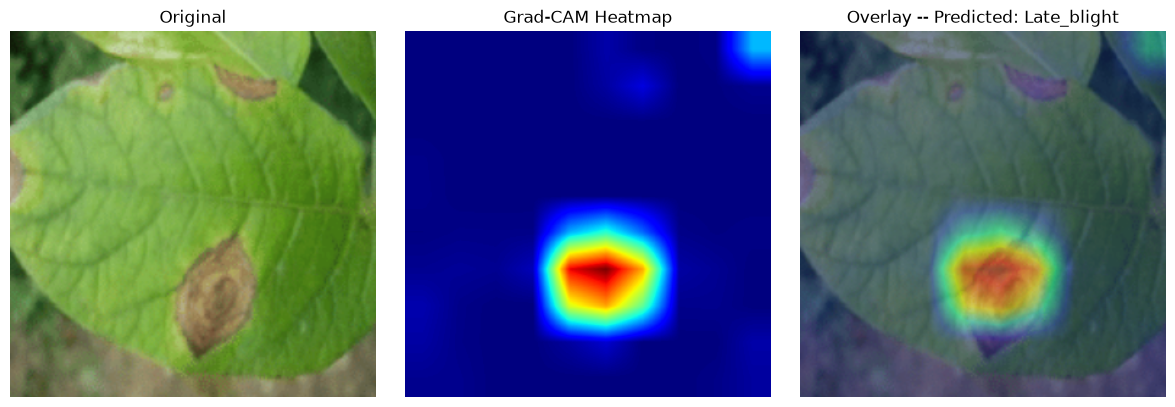

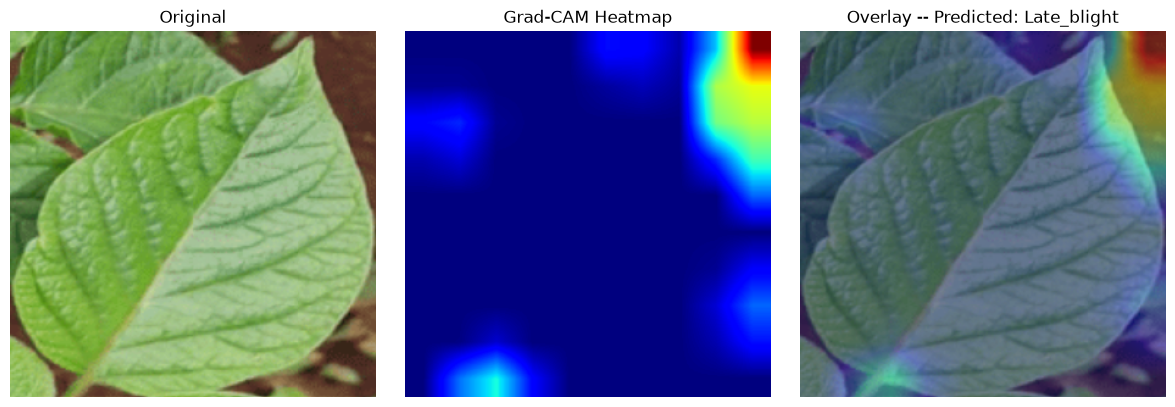

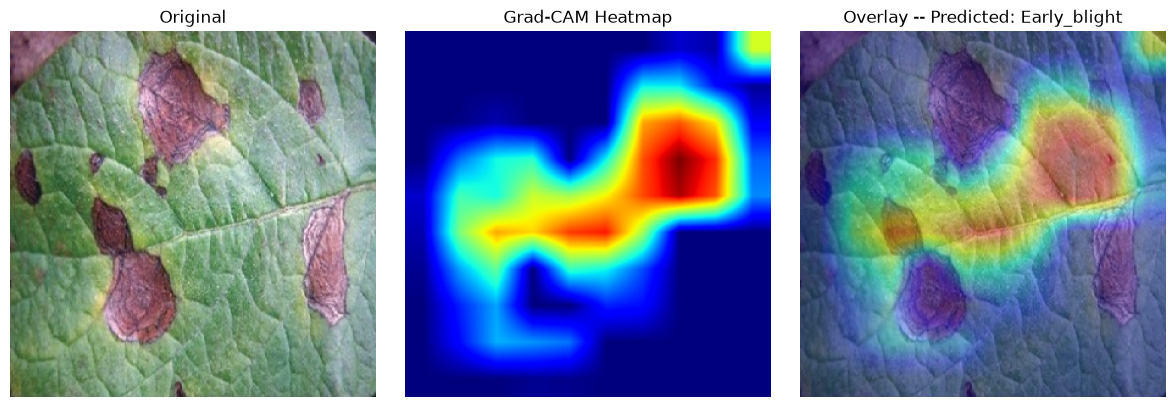

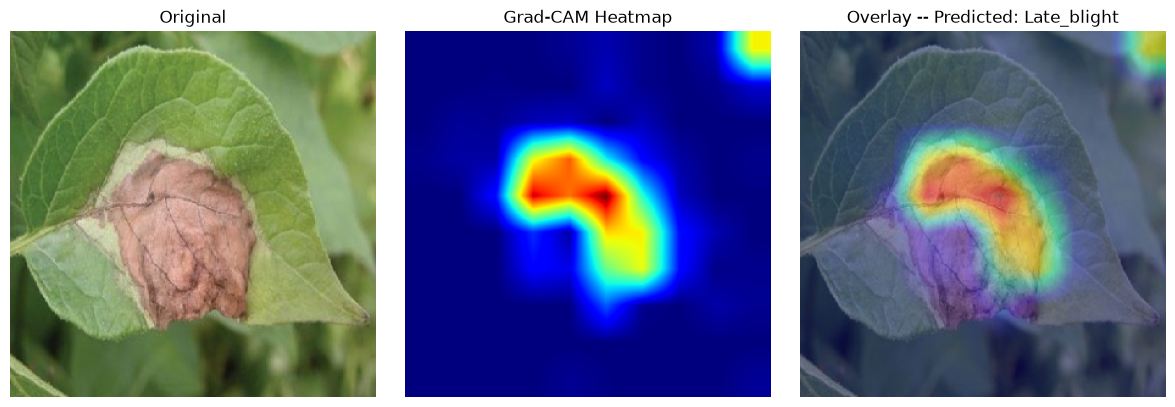

In [23]:
wrong_image_paths = [
    'External_Test_Data/Screenshot 2026-07-06 122101.png',
    'External_Test_Data/Screenshot 2026-07-06 122038.png',
    'External_Test_Data/lifi.jpeg',
    'External_Test_Data/late_blight.jpeg'
]

for path in wrong_image_paths:
    show_gradcam(path, model_eff_ft, eff_preprocess, (300, 300), CLASS_NAMES)

Found 3800 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Found 323 images belonging to 3 classes.
Epoch 1/60


I0000 00:00:1783328951.474210   58748 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61018__.53


132/237 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5545 - loss: 0.8307

I0000 00:00:1783328969.767153   58747 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_61018__.53


237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.6705 - loss: 0.6476 - val_accuracy: 0.8125 - val_loss: 0.4670 - learning_rate: 0.0010
Epoch 2/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.5468 - val_accuracy: 0.8156 - val_loss: 0.4851 - learning_rate: 0.0010
Epoch 3/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9141 - loss: 0.2143 - val_accuracy: 0.9438 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 4/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8750 - loss: 0.4263 - val_accuracy: 0.9656 - val_loss: 0.0991 - learning_rate: 0.0010
Epoch 5/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9234 - loss: 0.1808 - val_accuracy: 0.9531 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 6/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.3886 - val_accuracy: 0.9625 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 7/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9337 - loss: 0.1670 - val_a

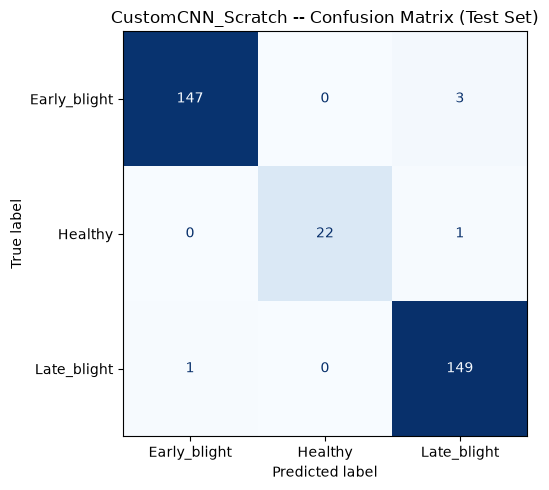

In [14]:
# Model 4: Custom CNN - trained from scratch 
K.clear_session()

simple_preprocess = lambda x: x / 255.0
train_gen, val_gen, test_gen = make_generators(simple_preprocess, target_size=(128, 128))
class_weights_dict = get_class_weights(train_gen)

model_cnn = build_custom_cnn(input_shape=(128, 128, 3))
model_cnn, results = train_and_evaluate('CustomCNN_Scratch', model_cnn,
                                          train_gen, val_gen, test_gen, class_weights_dict,
                                          epochs=60, patience=10)
all_results['CustomCNN_Scratch'] = results
trained_models['CustomCNN_Scratch'] = model_cnn


## 6. Model Comparison

In [39]:
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Test Accuracy': r.get('test_accuracy'),
        'Test F1 (macro)': r.get('test_f1_macro')
    }
    for name, r in all_results.items()
]).sort_values(
    'Test F1 (macro)',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

print(comparison_df.to_string(index=False))

                   Model  Test Accuracy  Test F1 (macro)
EfficientNetB3_FineTuned       0.996904         0.991793
       CustomCNN_Scratch       0.984520         0.982618
   EfficientNetB3_Frozen       0.987616         0.973164
             MobileNetV2       0.972136         0.946555


In [35]:
trained_models = {
    "EfficientNetB3_Frozen": model_eff_frozen,
    "EfficientNetB3_FineTuned": model_eff_ft,
    "MobileNetV2": model_mobilenet,
    "CustomCNN_Scratch": model_cnn,
}

Best model by test F1: EfficientNetB3_FineTuned


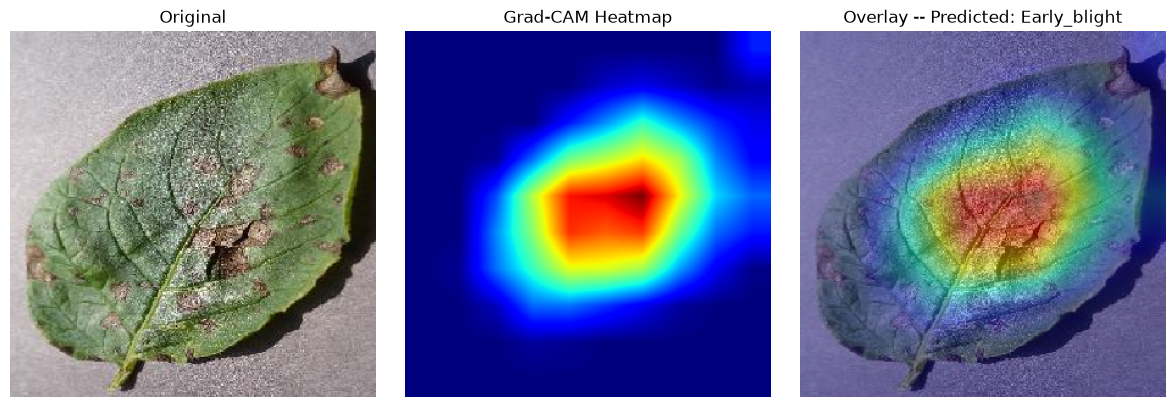

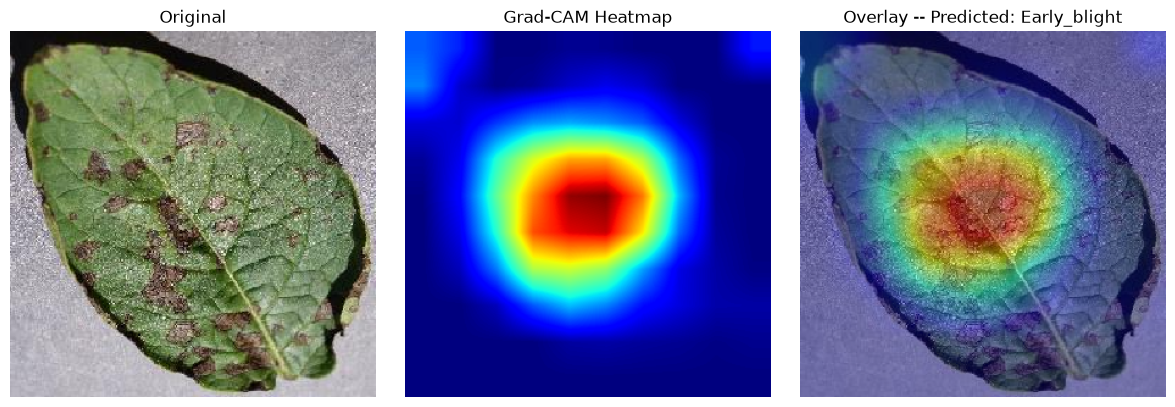

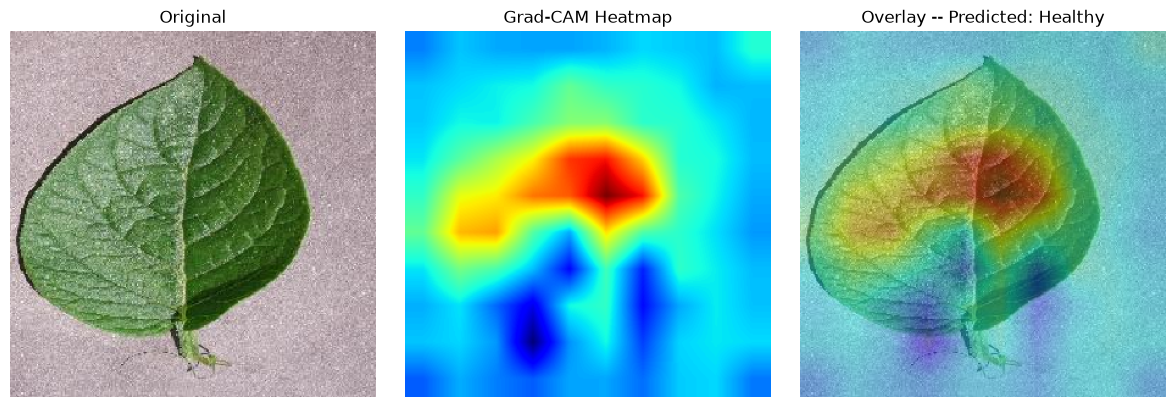

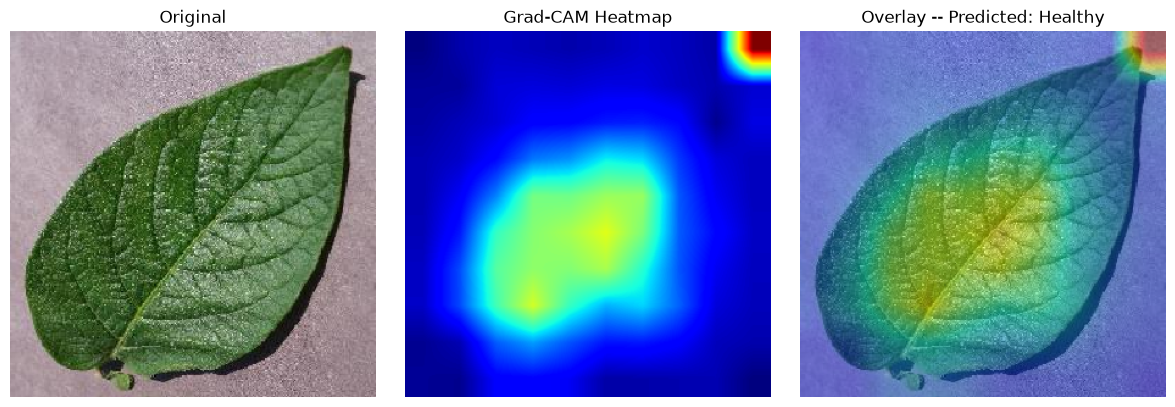

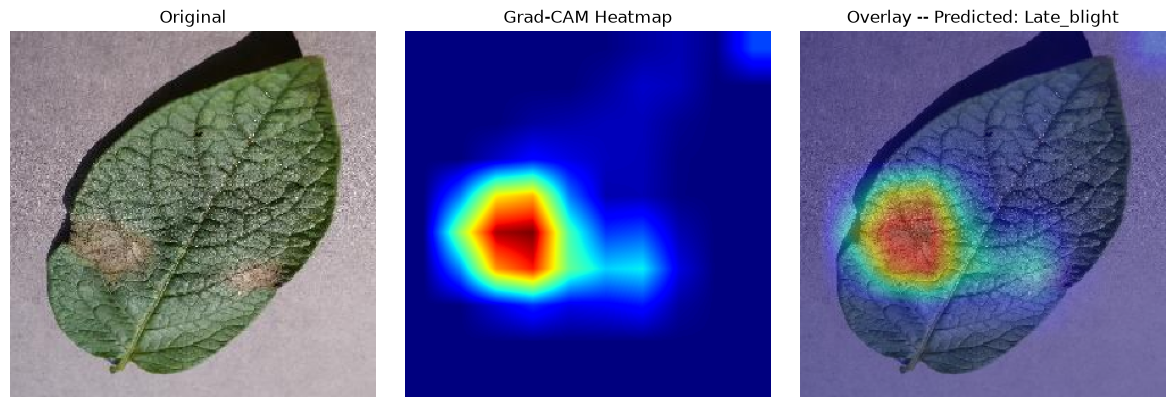

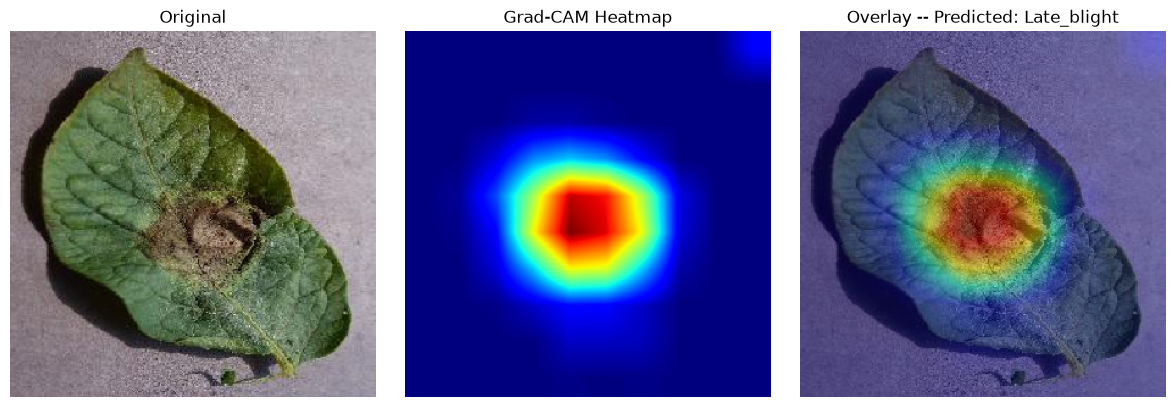

In [36]:
best_model_key = comparison_df.iloc[0]['Model']
print("Best model by test F1:", best_model_key)

gradcam_config = {
    'EfficientNetB3_Frozen':    {'target_size': (300, 300), 'preprocess': eff_preprocess},
    'EfficientNetB3_FineTuned': {'target_size': (300, 300), 'preprocess': eff_preprocess},
    'MobileNetV2':              {'target_size': (224, 224), 'preprocess': mobilenet_preprocess},
    'CustomCNN_Scratch':        {'target_size': (128, 128), 'preprocess': (lambda x: x / 255.0)},
}

cfg = gradcam_config[best_model_key]
best_model_obj = trained_models[best_model_key]


sample_paths = []
for c in CLASS_NAMES:
    class_test_dir = os.path.join(test_dir, c)
    files = os.listdir(class_test_dir)[:2]
    sample_paths.extend([os.path.join(class_test_dir, f) for f in files])

for path in sample_paths:
    show_gradcam(path, best_model_obj, cfg['preprocess'], cfg['target_size'], CLASS_NAMES)


## 8. Save Model

In [44]:
model_configs = {
    'EfficientNetB3_Frozen':    {'target_size': [300, 300], 'preprocess': 'efficientnet'},
    'EfficientNetB3_FineTuned': {'target_size': [300, 300], 'preprocess': 'efficientnet'},
    'MobileNetV2':              {'target_size': [224, 224], 'preprocess': 'mobilenet_v2'},
    'CustomCNN_Scratch':        {'target_size': [128, 128], 'preprocess': 'rescale'},
}

deployment_config = model_configs[best_model_key].copy()
deployment_config['model_name'] = best_model_key
deployment_config['class_names'] = CLASS_NAMES

with open('../deployment_config.json', 'w') as f:
    json.dump(deployment_config, f, indent=2)

shutil.copy(f'best_{best_model_key}.keras', '../potato_disease_final_model.keras')

print("Saved")
print(json.dumps(deployment_config, indent=2))


Saved
{
  "target_size": [
    300,
    300
  ],
  "preprocess": "efficientnet",
  "model_name": "EfficientNetB3_FineTuned",
  "class_names": [
    "Early_blight",
    "Healthy",
    "Late_blight"
  ]
}
